# Model Inference Analysis — Shared XGBoost and GAM Workflow


## 1. Imports and Configuration


In [ ]:
# Core libraries
import warnings
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import PartialDependenceDisplay

import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

MODEL_ID = 'xgboost'
RUN_NAME = "nusc_mini_debug_tpp-11_Mar_2026_15_29_02"
TARGET_COL = None  # Optional override, e.g. 'ml_ade_log'

RESULTS_ROOT = Path('../../results/interpretable_model') / MODEL_ID / RUN_NAME
TABLES_DIR = RESULTS_ROOT / 'tables'
PLOTS_DIR = RESULTS_ROOT / 'plots'

print(f'Results root: {RESULTS_ROOT.resolve()}')
print(f'Model ID: {MODEL_ID}')
print(f'Run: {RUN_NAME}')
print(f'TARGET_COL override: {TARGET_COL}')


Results root: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02
Model ID: gam
Run: nusc_mini_debug_tpp-11_Mar_2026_15_29_02
TARGET_COL override: None


## 2. Load Run Manifest and Final-Model Artifacts


In [2]:
def resolve_manifest_path(model_id, run_name, target_col=None):
    manifest_dir = Path('../../results/interpretable_model') / model_id / run_name / 'tables'
    if not manifest_dir.exists():
        raise FileNotFoundError(f'No tables directory found for model_id={model_id}, run_name={run_name}: {manifest_dir}')

    if target_col is not None:
        manifest_path = manifest_dir / f'run_manifest_{target_col}.json'
        if not manifest_path.exists():
            raise FileNotFoundError(f'Run manifest not found for target_col={target_col}: {manifest_path}')
        return manifest_path

    manifest_candidates = sorted(manifest_dir.glob('run_manifest_*.json'))
    if not manifest_candidates:
        raise FileNotFoundError(f'No run_manifest_*.json files found in {manifest_dir}')
    if len(manifest_candidates) > 1:
        raise ValueError(
            f'Multiple run manifests found in {manifest_dir}. Set TARGET_COL explicitly. '
            f'Candidates: {[p.name for p in manifest_candidates]}'
        )
    return manifest_candidates[0]


manifest_path = resolve_manifest_path(MODEL_ID, RUN_NAME, TARGET_COL)
manifest = json.loads(manifest_path.read_text())

if manifest['model_id'] != MODEL_ID:
    raise ValueError(f"Manifest model_id={manifest['model_id']} does not match MODEL_ID={MODEL_ID}")
if manifest['model_id'] not in {'xgboost', 'gam'}:
    raise NotImplementedError(f"Model inference analysis is not implemented yet for model_id={manifest['model_id']}")

target_col = manifest['target_col']
feature_cols = manifest['feature_cols']
TABLES_DIR = Path(manifest['tables_dir'])
PLOTS_DIR = Path(manifest['plots_dir'])

nested_resampling = manifest['nested_resampling']
final_model = manifest['final_model']
model_data_path = Path(nested_resampling['model_data_with_oof_path'])
model_path = Path(final_model['model_path'])
full_data_tuning_summary_path = Path(final_model['full_data_tuning_summary_path'])
full_data_tuning_summary = json.loads(full_data_tuning_summary_path.read_text())

model_df_oof = pd.read_csv(model_data_path)
X = model_df_oof[feature_cols]

if MODEL_ID == 'xgboost':
    model = xgb.XGBRegressor()
    model.load_model(model_path)
    X_for_model = X
    selected_variant_name = 'XGBoost'
elif MODEL_ID == 'gam':
    scaler_path = Path(final_model['scaler_path'])
    with model_path.open('rb') as f:
        model = pickle.load(f)
    with scaler_path.open('rb') as f:
        scaler = pickle.load(f)
    X_for_model = scaler.transform(X)
    selected_variant_name = final_model['selected_variant_name']
    selected_target_mode = final_model['selected_variant_target_mode']
else:
    raise NotImplementedError(f'Model inference analysis is not implemented yet for model_id={MODEL_ID}')

print(f'Loaded manifest: {manifest_path}')
print(f'Loaded model data: {model_data_path}')
print(f'Loaded final model: {model_path}')
print(f'Target: {target_col} | Features: {len(feature_cols)}')
print(f'Selected variant: {selected_variant_name}')
print('Final-model tuning summary:')
print(json.dumps(full_data_tuning_summary, indent=2))


Loaded manifest: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/run_manifest_ml_ade_log.json
Loaded model data: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/model_data_with_oof_ml_ade_log.csv
Loaded final model: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/gam_model_ml_ade_log.pkl
Target: ml_ade_log | Features: 13
Selected variant: GammaGAM
Final-model tuning summary:
{
  "model_id": "gam",
  "run_name": "nusc_mini_debug_tpp-11_Mar_2026_15_29_02",
  "target_col": "ml_ade_log",
  "raw_target_col": "ml_ade",
  "log_target_col": "ml_ade_log",
  "selection_metric_name": "rmse_original_scale",
  "variant_results": [
    {
      "variant_name": "LinearGAM (log)",
      "model_kind": "linear",
      "target_mode": "log",
      "status": "completed",
      "best_params": {
        "n_splines": 23,
        "spline_order": 4,
        "lam": 2.7558841198831323
      },
      "best_cv_

## 3. Feature Importance / Global Interpretability


,feature,p_value,neg_log10_p_value,significant_0_05
0,max_speed,1.110223e-16,15.954590,True
1,heading_change,7.344569e-06,5.134034,True
2,mean_acceleration,5.566552e-05,4.254414,True
3,std_speed,6.662001e-04,3.176395,True
4,scene_spatial_density,3.212975e-01,0.493093,False
5,has_collision,3.899924e-01,0.408944,False
6,scene_bbox_height,5.188391e-01,0.284967,False
7,min_neighbor_distance,5.886542e-01,0.230140,False
8,mean_jerk,6.108047e-01,0.214098,False
9,scene_num_agents,8.176778e-01,0.087418,False


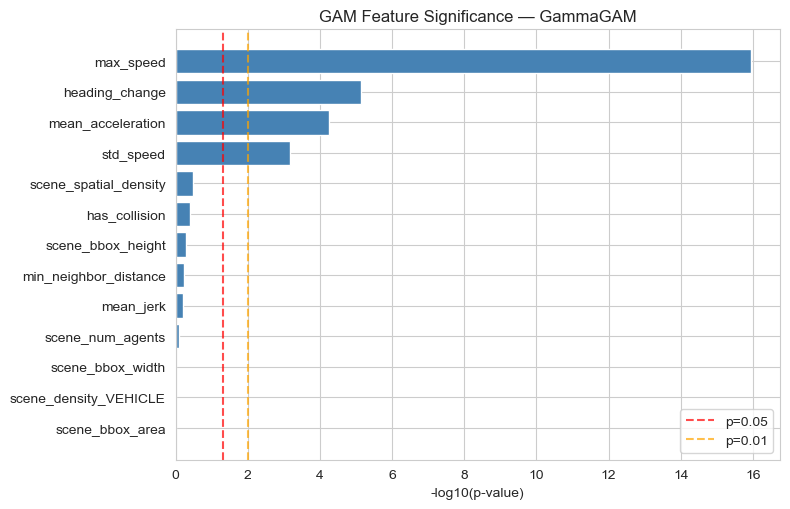

Feature significance table saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/feature_significance_ml_ade_log.csv
Feature significance plot saved to:  ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots/feature_significance_ml_ade_log.png
Features selected for downstream effect plots (up to 16, ranked):
['max_speed', 'heading_change', 'mean_acceleration', 'std_speed', 'scene_spatial_density', 'has_collision', 'scene_bbox_height', 'min_neighbor_distance', 'mean_jerk', 'scene_num_agents', 'scene_bbox_width', 'scene_density_VEHICLE', 'scene_bbox_area']


In [3]:
if MODEL_ID == 'xgboost':
    explainer = shap.Explainer(model, X_for_model)
    shap_exp = explainer(X_for_model)
    shap_values = shap_exp.values

    shap_importance_df = pd.DataFrame({
        'feature': X.columns,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0),
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    display(shap_importance_df)

    importance_table_path = TABLES_DIR / f'shap_importance_{target_col}.csv'
    shap_importance_df.to_csv(importance_table_path, index=False)
    ranked_features = shap_importance_df['feature'].tolist()
    effect_features = ranked_features[:16]

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_for_model, show=False, max_display=20)
    beeswarm_path = PLOTS_DIR / f'shap_beeswarm_{target_col}.png'
    plt.tight_layout()
    plt.savefig(beeswarm_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_for_model, plot_type='bar', show=False, max_display=20)
    importance_plot_path = PLOTS_DIR / f'shap_bar_{target_col}.png'
    plt.tight_layout()
    plt.savefig(importance_plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f'SHAP importance table saved to: {importance_table_path}')
    print(f'SHAP beeswarm saved to: {beeswarm_path}')
    print(f'SHAP bar saved to:      {importance_plot_path}')
elif MODEL_ID == 'gam':
    p_values = np.asarray(model.statistics_['p_values'][:len(feature_cols)], dtype=float)
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'p_value': p_values,
        'neg_log10_p_value': -np.log10(np.maximum(p_values, 1e-300)),
        'significant_0_05': p_values < 0.05,
    }).sort_values('p_value').reset_index(drop=True)

    display(importance_df)

    importance_table_path = TABLES_DIR / f'feature_significance_{target_col}.csv'
    importance_df.to_csv(importance_table_path, index=False)
    ranked_features = importance_df['feature'].tolist()
    effect_features = ranked_features[:16]

    fig, ax = plt.subplots(figsize=(8, max(4, len(feature_cols) * 0.4)))
    plot_df = importance_df.sort_values('neg_log10_p_value', ascending=True)
    ax.barh(plot_df['feature'], plot_df['neg_log10_p_value'], color='steelblue')
    ax.axvline(x=-np.log10(0.05), color='red', linestyle='--', label='p=0.05', alpha=0.7)
    ax.axvline(x=-np.log10(0.01), color='orange', linestyle='--', label='p=0.01', alpha=0.7)
    ax.set_xlabel('-log10(p-value)')
    ax.set_title(f'GAM Feature Significance — {selected_variant_name}')
    ax.legend()
    plt.tight_layout()
    importance_plot_path = PLOTS_DIR / f'feature_significance_{target_col}.png'
    plt.savefig(importance_plot_path, dpi=150, bbox_inches='tight')
    plt.show()

    beeswarm_path = None
    print(f'Feature significance table saved to: {importance_table_path}')
    print(f'Feature significance plot saved to:  {importance_plot_path}')
else:
    raise NotImplementedError(f'Model inference analysis is not implemented yet for model_id={MODEL_ID}')

print('Features selected for downstream effect plots (up to 16, ranked):')
print(effect_features)


## 4. Feature Effect Plots


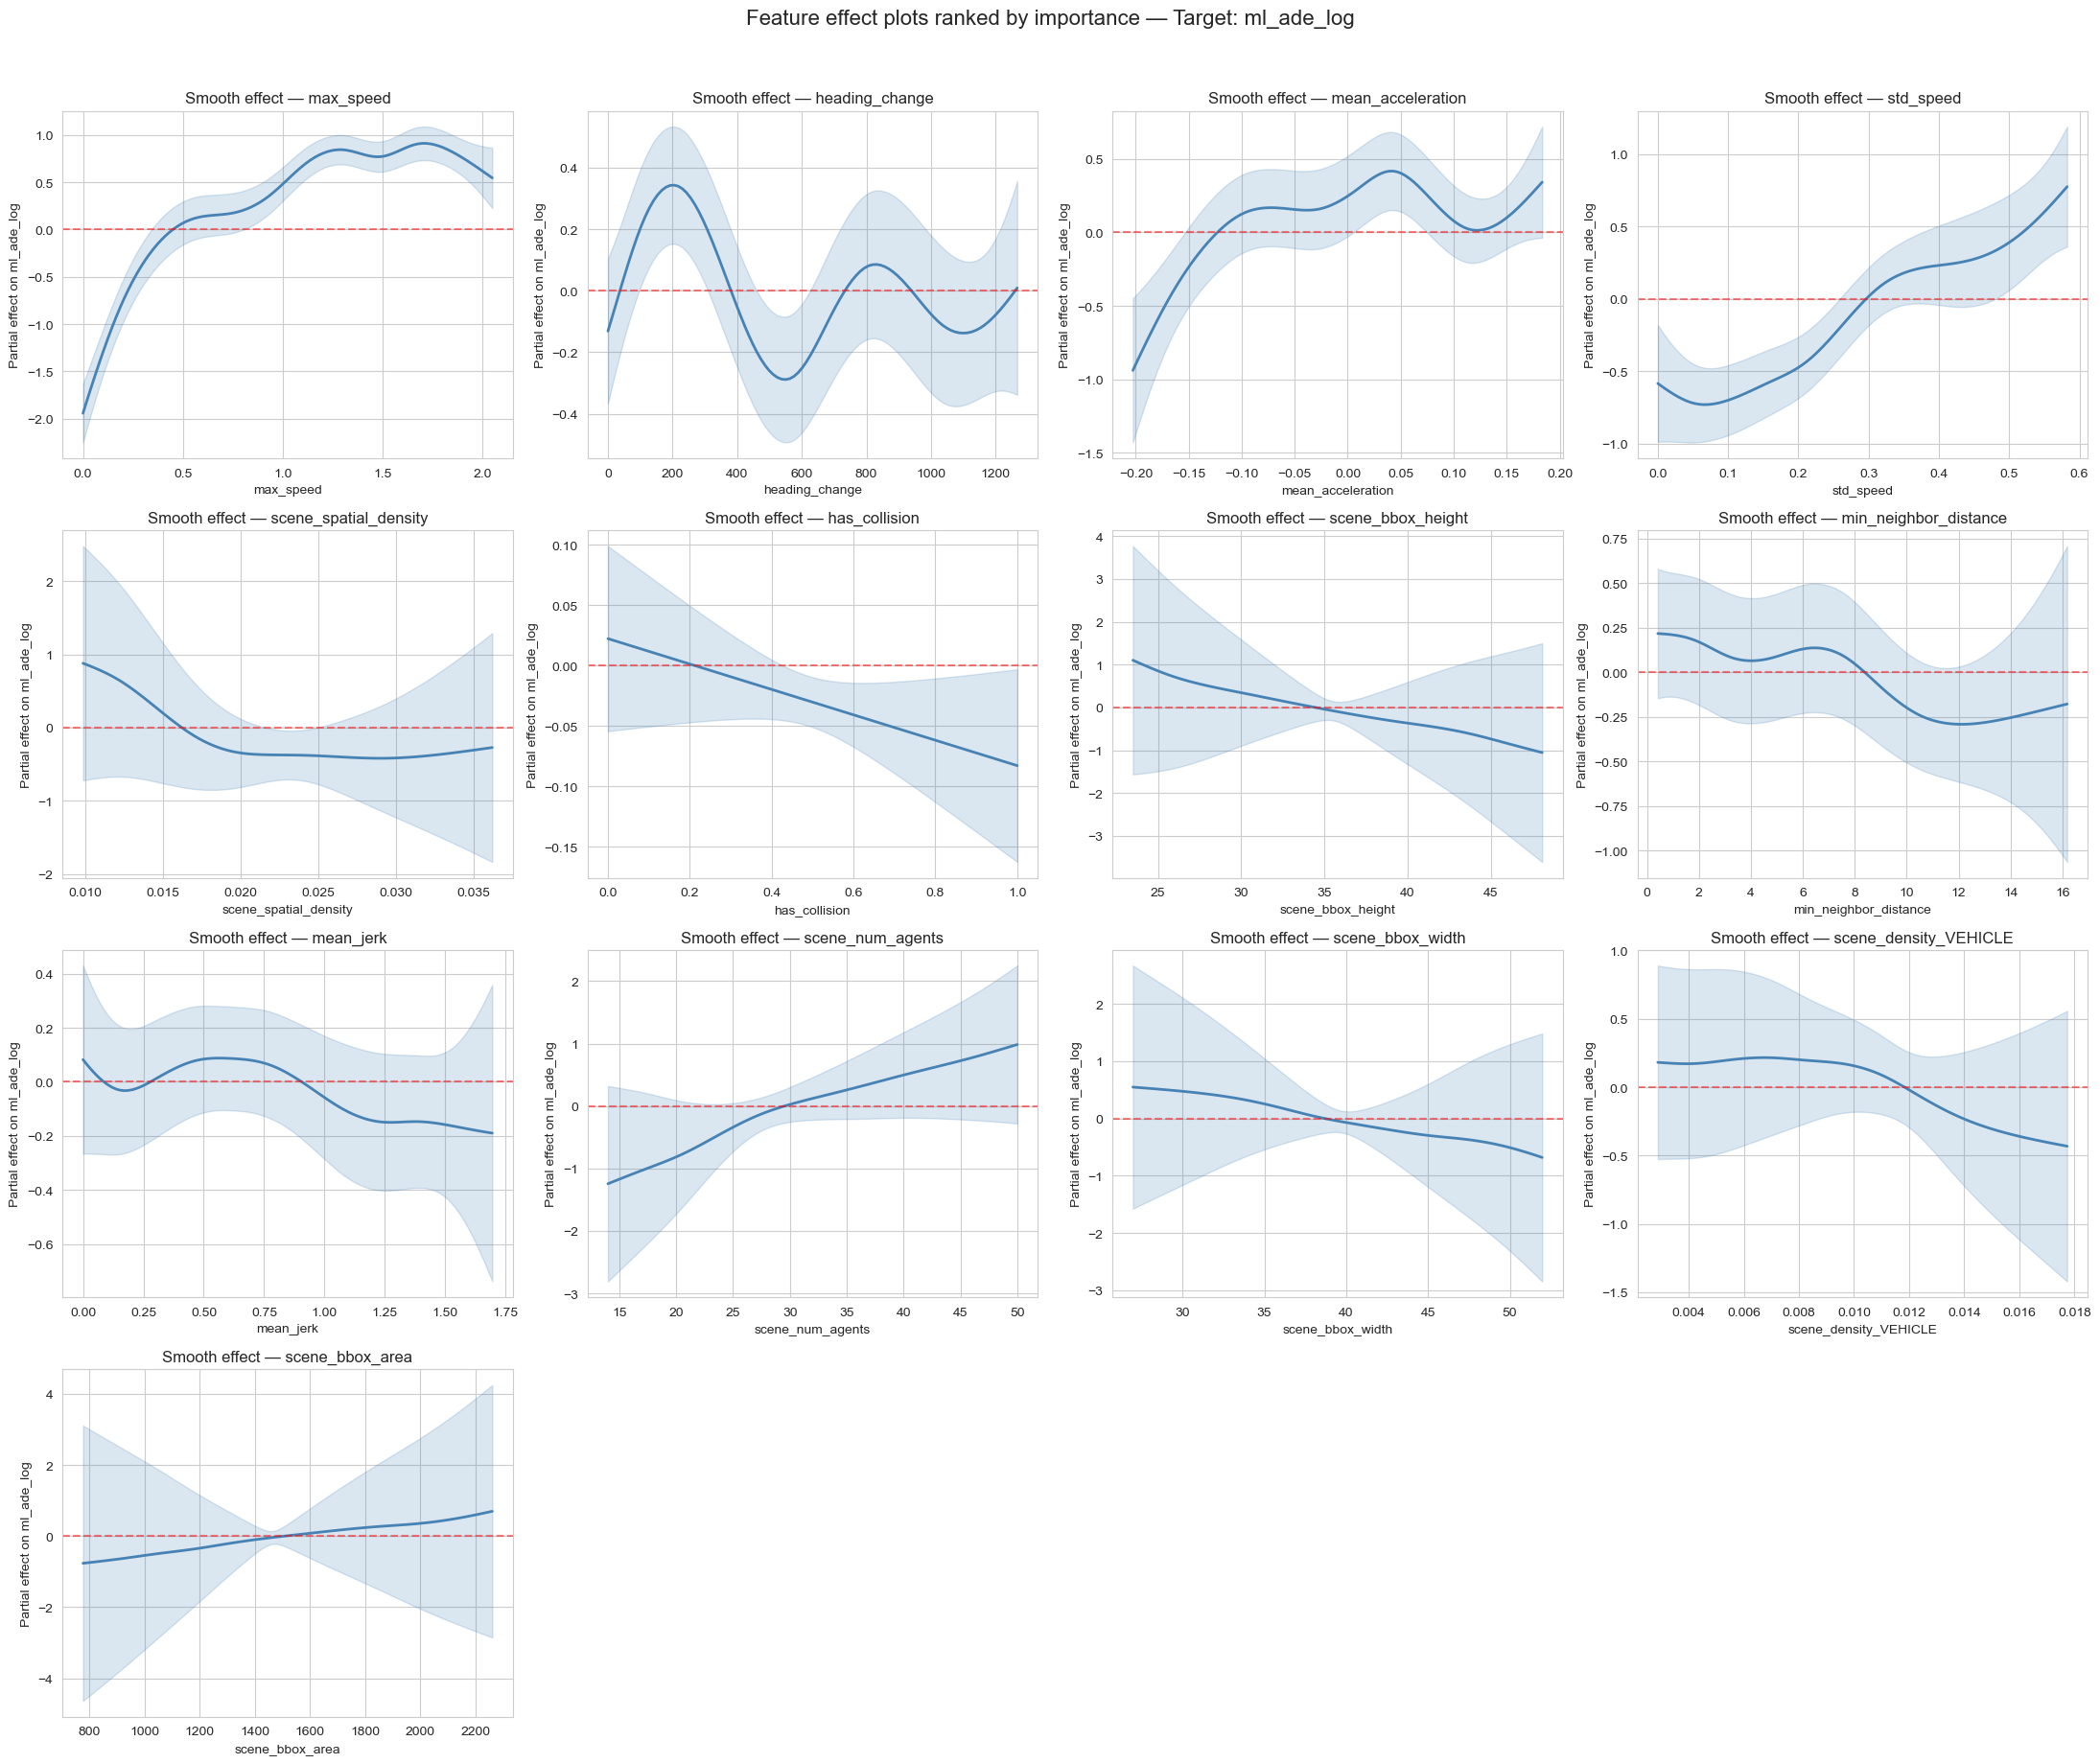

Feature effect grid saved for the ranked feature set.
Feature effect grid path: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots/feature_effects_grid_ml_ade_log.png


In [4]:
fig, axes = plt.subplots(4, 4, figsize=(22, 18))
axes = axes.flatten()

if MODEL_ID == 'xgboost':
    for ax, feat in zip(axes, effect_features):
        PartialDependenceDisplay.from_estimator(
            model,
            X_for_model,
            features=[feat],
            kind='average',
            grid_resolution=40,
            ax=ax,
        )
        ax.set_title(f'PDP — {feat}')
elif MODEL_ID == 'gam':
    for ax, feat in zip(axes, effect_features):
        feat_idx = feature_cols.index(feat)
        XX = model.generate_X_grid(term=feat_idx)
        pdep, confi = model.partial_dependence(term=feat_idx, X=XX, width=0.95)
        x_scaled = XX[:, feat_idx]
        x_original = x_scaled * scaler.scale_[feat_idx] + scaler.mean_[feat_idx]

        ax.plot(x_original, pdep, color='steelblue', linewidth=2)
        ax.fill_between(x_original, confi[:, 0], confi[:, 1], alpha=0.2, color='steelblue')
        ax.axhline(0, color='red', linestyle='--', alpha=0.5)
        ax.set_title(f'Smooth effect — {feat}')
        ax.set_xlabel(feat)
        ylabel = f'Partial effect on {target_col}' if selected_target_mode != 'log' else f'Partial effect on {target_col} (log scale)'
        ax.set_ylabel(ylabel)
else:
    raise NotImplementedError(f'Model inference analysis is not implemented yet for model_id={MODEL_ID}')

for ax in axes[len(effect_features):]:
    ax.set_visible(False)

plt.suptitle(f'Feature effect plots ranked by importance — Target: {target_col}', fontsize=16, y=1.02)
plt.tight_layout()
effect_plot_path = PLOTS_DIR / f'feature_effects_grid_{target_col}.png'
plt.savefig(effect_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print('Feature effect grid saved for the ranked feature set.')
print(f'Feature effect grid path: {effect_plot_path}')


## 5. Saved Artifacts


In [5]:
print('Saved artifacts:')
print(f'- Run manifest:            {manifest_path}')
print(f'- Final model:             {model_path}')
print(f'- Tuning summary:          {full_data_tuning_summary_path}')
print(f'- Importance table:        {importance_table_path}')
print(f'- Importance plot:         {importance_plot_path}')
print(f'- Effect plot grid:        {effect_plot_path}')
if MODEL_ID == 'xgboost':
    print(f'- SHAP beeswarm:           {beeswarm_path}')
if MODEL_ID == 'gam':
    print(f'- Scaler:                  {scaler_path}')
print(f'- Plot directory:          {PLOTS_DIR}')


Saved artifacts:
- Run manifest:            ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/run_manifest_ml_ade_log.json
- Final model:             ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/gam_model_ml_ade_log.pkl
- Tuning summary:          ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/full_data_tuning_optuna_summary_ml_ade_log.json
- Importance table:        ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/feature_significance_ml_ade_log.csv
- Importance plot:         ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots/feature_significance_ml_ade_log.png
- Effect plot grid:        ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots/feature_effects_grid_ml_ade_log.png
- Scaler:                  ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_0